In [1]:
# pip install chess zstandard lightgbm pandas scikit-learn matplotlib joblib
import io, re, time, os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zstandard as zstd
# import lightgbm as lgb

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import randint, uniform
from joblib import Parallel, delayed

from chess_features_final import extract_features_dataframe, compute_elo_sample_weights
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
import scipy.stats as stats
import random

print('All imports OK')

All imports OK


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION — edit everything here, nowhere else
# ═══════════════════════════════════════════════════════════════════════════════

DATA_PATH    = "../../data/elias_data/lichess_db_standard_rated_2017-05.pgn.zst"
MAX_GAMES    = 100_000
RANDOM_STATE = 42
N_JOBS       = -1          # -1 = all CPU cores

# ── splits ────────────────────────────────────────────────────────────────────
VAL_SIZE     = 0.10        # fraction of total data for validation
TEST_SIZE    = 0.10        # fraction of total data for test (rest = train)

# ── time-control filter ───────────────────────────────────────────────────────
# Set to None to keep all games, or e.g. 600 to keep only 10-min games.
# Matches the base time in seconds from the TimeControl header (e.g. '600+0').
FILTER_BASE_SECONDS = None   # e.g. 600, 300, 180, 60, None

# ── data quality filters ──────────────────────────────────────────────────────
FILTER_SHORT_GAMES   = True
MIN_TOTAL_PLIES      = 12
EXCLUDE_TERMINATIONS = {"Time forfeit", "Abandoned", "Unterminated"}

# ── feature groups — set True/False to include/exclude each block ─────────────
FEATURE_GROUPS = {
    'structure':  True,   # ply count, material, result
    'checks':     True,   # checks given, check density
    'captures':   True,   # first capture, pawn/piece captures, capture density
    'castling':   True,   # castle move number + side (categorical)
    'style':      True,   # consecutive moves, queen early, territory depth,
                          #   promotions, en passant, legal moves on move 5
    'clock':      True,   # avg/std/max time, time pressure, opening pace,
                          #   clock remaining (normalised to game duration)
    'engine':     False,  # ACPL, inaccuracies, mistakes, blunders, blunder density
                          #   (NaN when [%eval] tags absent — imputed by median)
    'meta':       False,  # TimeControl + ECO one-hot
}

# ── meta handling ─────────────────────────────────────────────────────────────
ADD_TIME_CONTROL_NUMERIC = True
ECO_COARSE_LEVEL = "letter"  # "letter" or None (only used when FEATURE_GROUPS['meta']=True)

# ── model ─────────────────────────────────────────────────────────────────────
LGBM_PARAMS = {
    'n_estimators':      500,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'random_state':      RANDOM_STATE,
    'verbose':           -1,
    'n_jobs':            N_JOBS,
}

# ── reuse saved models (skip training) ─────────────────────────────────────────
LOAD_PRETRAINED_MODELS = False
PRETRAINED_WHITE_PATH  = None  # e.g. "lgb_elo_500000_notes_whiteelo_YYYYMMDD_HHMMSS.txt"
PRETRAINED_BLACK_PATH  = None  # e.g. "lgb_elo_500000_notes_blackelo_YYYYMMDD_HHMMSS.txt"

# ── hyperparam search (toggle off once you've found good values) ───────────────
RUN_HYPERPARAM_SEARCH  = False
HYPERPARAM_N_ITER      = 20       # number of random configs to try
HYPERPARAM_CV_FOLDS    = 3
HYPERPARAM_SEARCH_SPACE = {
    'n_estimators':      randint(200, 800),
    'learning_rate':     uniform(0.01, 0.1),
    'num_leaves':        randint(31, 127),
    'min_child_samples': randint(10, 50),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
}

# ── feature importance ─────────────────────────────────────────────────────────
RUN_PERM_IMPORTANCE    = True
FEATURE_IMPORTANCE_METHOD = "gain"  # "gain", "split", or "permutation"
PERM_N_REPEATS         = 5
TOP_N_FEATURES         = 15       # used for optional retrain
RETRAIN_TOP_N          = False     # retrain model using only top-N features

# ── output ────────────────────────────────────────────────────────────────────
VERBOSE_PLOTS          = True
# Model filenames: set a base name; timestamp is appended automatically
MODEL_SAVE_NAME  = f'lgb_elo_{MAX_GAMES}'
MODEL_SAVE_NOTES = '600s_no_meta'   # describe what's special — change per run
ELO_BINS = [0, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500, 4000]

# ═══════════════════════════════════════════════════════════════════════════════
#  Derived feature lists — built from FEATURE_GROUPS above
# ══════════════════════

_BOARD_FEATURES = {
    'structure': ['total_ply_count', 'material_balance_end', 'result_encoded'],
    'checks':    ['checks_given_white', 'checks_given_black',
                  'check_density_white', 'check_density_black'],
    'captures':  ['first_capture_move_white', 'first_capture_move_black',
                  'pawn_captures_total', 'piece_captures_total', 'capture_density'],
    'castling':  ['castle_move_white', 'castle_move_black'],
    'style':     ['consec_same_piece_white', 'consec_same_piece_black',
                  'queen_moves_before_10', 'white_territory_depth', 'black_territory_depth',
                  'promotions', 'en_passant_captures',
                  'legal_moves_white_move5', 'legal_moves_black_move5'],
    'engine':    ['acpl_white', 'inaccuracy_count_white', 'mistake_count_white',
                  'blunder_count_white', 'blunder_density_white',
                  'acpl_black', 'inaccuracy_count_black', 'mistake_count_black',
                  'blunder_count_black', 'blunder_density_black'],
}
_CLOCK_FEATURES = [
    'avg_time_norm_white', 'std_time_norm_white', 'max_time_norm_white',
    'time_pressure_white', 'opening_pace_norm_white', 'clock_remaining_norm_white',
    'opening_time_norm_white', 'endgame_time_norm_white', 'time_spent_trend_norm_white',
    'avg_time_norm_black', 'std_time_norm_black', 'max_time_norm_black',
    'time_pressure_black', 'opening_pace_norm_black', 'clock_remaining_norm_black',
    'opening_time_norm_black', 'endgame_time_norm_black', 'time_spent_trend_norm_black',
]
_CASTLE_CAT = ['castle_side_white', 'castle_side_black'] if FEATURE_GROUPS['castling'] else []

_META_CAT = []
if FEATURE_GROUPS['meta']:
    if ECO_COARSE_LEVEL == "letter":
        _META_CAT = ['TimeControl', 'ECO_Group']
    else:
        _META_CAT = ['TimeControl', 'ECO']

_TC_NUMERIC = ['tc_base', 'tc_increment'] if ADD_TIME_CONTROL_NUMERIC else []

NUMERIC_FEATURES = []
for grp, cols in _BOARD_FEATURES.items():
    if FEATURE_GROUPS.get(grp, False):
        NUMERIC_FEATURES += cols
if FEATURE_GROUPS['clock']:
    NUMERIC_FEATURES += _CLOCK_FEATURES
NUMERIC_FEATURES += _TC_NUMERIC

CATEGORICAL_FEATURES = _CASTLE_CAT + _META_CAT

print('Numeric features  :', len(NUMERIC_FEATURES))
print('Categorical groups:', CATEGORICAL_FEATURES[:4], '...')
print('Feature groups    :', {k: v for k,v in FEATURE_GROUPS.items()})

Numeric features  : 43
Categorical groups: ['castle_side_white', 'castle_side_black'] ...
Feature groups    : {'structure': True, 'checks': True, 'captures': True, 'castling': True, 'style': True, 'clock': True, 'engine': False, 'meta': False}


In [3]:
# import io
# import time
# import pandas as pd
# import zstandard as zstd

CHUNK_SIZE = 100000  # Convert to DataFrame in batches to save RAM!
df_chunks = []
games_list = []
games_processed = 0

dctx = zstd.ZstdDecompressor()
t0 = time.time()

with open(DATA_PATH, 'rb') as compressed_file:
    with dctx.stream_reader(compressed_file) as reader:
        text_stream = io.TextIOWrapper(reader, encoding='utf-8')
        current_game = {}
        
        for line in text_stream:
            line = line.strip()
            
            if line.startswith('['):
                tag = line.split(' ')[0][1:]
                # Safe split just in case there's malformed PGN data
                if '"' in line:
                    val = line.split('"')[1]
                    if tag in ('WhiteElo', 'BlackElo', 'TimeControl', 'ECO',
                               'Termination', 'Result'):
                        current_game[tag] = val
                        
            elif line.startswith('1.'):
                current_game['Moves'] = line
                if 'WhiteElo' in current_game and 'BlackElo' in current_game:
                    games_list.append(current_game)
                    games_processed += 1
                
                current_game = {}
                
                # --- THE MLOps FIX: MEMORY CHUNKING ---
                if len(games_list) >= CHUNK_SIZE:
                    print(f"Parsed {games_processed:,} games, compressing chunk to DataFrame...")
                    df_chunks.append(pd.DataFrame(games_list))
                    games_list = []  # Completely clear the heavy dictionary list from RAM!
                    
                if games_processed >= MAX_GAMES:
                    break

# Catch any leftover games in the final chunk
if games_list:
    df_chunks.append(pd.DataFrame(games_list))

print("Concatenating all chunks into one DataFrame...")
df_raw = pd.concat(df_chunks, ignore_index=True)

# Free up the chunk list memory
del df_chunks 
del games_list

# --- Original Type Conversions ---
df_raw['WhiteElo'] = pd.to_numeric(df_raw['WhiteElo'], errors='coerce')
df_raw['BlackElo'] = pd.to_numeric(df_raw['BlackElo'], errors='coerce')
df_raw = df_raw.dropna(subset=['WhiteElo', 'BlackElo']).copy()
df_raw['WhiteElo'] = df_raw['WhiteElo'].astype(int)
df_raw['BlackElo'] = df_raw['BlackElo'].astype(int)
df_raw['Moves']    = df_raw['Moves'].fillna('').astype(str)

print(f'Loaded {len(df_raw):,} games in {time.time()-t0:.1f}s')

# ── optional time-control filter ──────────────────────────────────────────────
if FILTER_BASE_SECONDS is not None:
    _tc_base = (
        df_raw['TimeControl'].astype(str)
        .str.extract(r'^(\d+)\+')[0]
        .astype(float)
    )
    df_raw = df_raw[_tc_base == FILTER_BASE_SECONDS].copy().reset_index(drop=True)
    print(f'After TC filter ({FILTER_BASE_SECONDS}s): {len(df_raw):,} games')

# ── optional termination filter ───────────────────────────────────────────────
if EXCLUDE_TERMINATIONS and 'Termination' in df_raw.columns:
    before = len(df_raw)
    df_raw = df_raw[~df_raw['Termination'].isin(EXCLUDE_TERMINATIONS)].copy().reset_index(drop=True)
    print(f'After termination filter: {len(df_raw):,} games (dropped {before-len(df_raw):,})')

# ── optional numeric time-control features ────────────────────────────────────
if ADD_TIME_CONTROL_NUMERIC and 'TimeControl' in df_raw.columns:
    _tc = df_raw['TimeControl'].astype(str).str.extract(r'^(\d+)\+(\d+)')
    df_raw['tc_base'] = pd.to_numeric(_tc[0], errors='coerce').fillna(0).astype(float)
    df_raw['tc_increment'] = pd.to_numeric(_tc[1], errors='coerce').fillna(0).astype(float)

df_raw.head(3)

Parsed 100,000 games, compressing chunk to DataFrame...
Concatenating all chunks into one DataFrame...
Loaded 100,000 games in 2.4s
After TC filter (600s): 15,374 games
After termination filter: 12,621 games (dropped 2,753)


,Result,WhiteElo,BlackElo,ECO,TimeControl,Termination,Moves,tc_base,tc_increment
0,1-0,1610,1575,C50,600+0,Normal,1. e4 { [%clk 0:10:00] } e5 { [%clk 0:10:00] }...,600.0,0.0
1,0-1,2058,2051,B08,600+0,Normal,1. e4 { [%clk 0:10:00] } d6 { [%clk 0:10:00] }...,600.0,0.0
2,0-1,1624,1638,C41,600+0,Normal,1. e4 { [%clk 0:10:00] } e5 { [%clk 0:05:00] }...,600.0,0.0


In [4]:
_CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+)\]')

def parse_clock_features(moves_string: str, time_control: str = '?') -> dict:
    clocks = [int(h)*3600 + int(m)*60 + int(s)
              for h, m, s in _CLK_RE.findall(moves_string)]
    clk_w, clk_b = clocks[0::2], clocks[1::2]

    tc_m      = re.match(r'(\d+)\+(\d+)', str(time_control))
    base      = int(tc_m.group(1)) if tc_m else None
    increment = int(tc_m.group(2)) if tc_m else 0
    norm      = base if base else 1   # normalise times to game duration

    def _spent(seq, start):
        out, prev = [], start
        for c in seq:
            if prev is not None:
                s = prev - c + increment
                if s >= 0: out.append(s)
            prev = c
        return out

    sw = _spent(clk_w, base)
    sb = _spent(clk_b, base)

    def _stats(seq):
        if not seq: return 0., 0., 0.
        a = np.array(seq)
        return float(a.mean()), float(a.std()), float(a.max())

    def _trend(seq):
        if len(seq) < 2:
            return 0.0
        x = np.arange(len(seq))
        slope = np.polyfit(x, np.array(seq, dtype=float), 1)[0]
        return float(slope)

    def _window_mean(seq, n=10, which='first'):
        if not seq:
            return 0.0
        if which == 'first':
            return float(np.mean(seq[:n]))
        return float(np.mean(seq[-n:]))

    aw, sw2, mw = _stats(sw)
    ab, sb2, mb = _stats(sb)

    return {
        'avg_time_norm_white':        aw / norm,
        'std_time_norm_white':        sw2 / norm,
        'max_time_norm_white':        mw / norm,
        'time_pressure_white':        sum(1 for c in clk_w if c < 10),
        'opening_pace_norm_white':    (np.mean(sw[:10]) if sw else 0.) / norm,
        'clock_remaining_norm_white': (clk_w[-1] / norm) if clk_w else 0.,
        'opening_time_norm_white':    _window_mean(sw, 10, 'first') / norm,
        'endgame_time_norm_white':    _window_mean(sw, 10, 'last') / norm,
        'time_spent_trend_norm_white': _trend(sw) / norm,
        'avg_time_norm_black':        ab / norm,
        'std_time_norm_black':        sb2 / norm,
        'max_time_norm_black':        mb / norm,
        'time_pressure_black':        sum(1 for c in clk_b if c < 10),
        'opening_pace_norm_black':    (np.mean(sb[:10]) if sb else 0.) / norm,
        'clock_remaining_norm_black': (clk_b[-1] / norm) if clk_b else 0.,
        'opening_time_norm_black':    _window_mean(sb, 10, 'first') / norm,
        'endgame_time_norm_black':    _window_mean(sb, 10, 'last') / norm,
        'time_spent_trend_norm_black': _trend(sb) / norm,
    }

if FEATURE_GROUPS['clock']:
    tc_col = df_raw['TimeControl'] if 'TimeControl' in df_raw.columns else ['?']*len(df_raw)
    clock_records = Parallel(n_jobs=N_JOBS)(
        delayed(parse_clock_features)(m, t)
        for m, t in zip(df_raw['Moves'], tc_col)
    )
    df_clocks = pd.DataFrame(clock_records, index=df_raw.index)
    print('Clock features:', df_clocks.shape)
else:
    df_clocks = pd.DataFrame(index=df_raw.index)
    print('Clock features skipped (FEATURE_GROUPS[clock]=False)')

Clock features: (12621, 18)


In [5]:
t0       = time.time()
df_feats = extract_features_dataframe(df_raw, n_jobs=N_JOBS)
elapsed  = time.time() - t0
print(f'Extracted {len(df_feats):,} games in {elapsed:.1f}s  ({elapsed/len(df_feats)*1000:.1f} ms/game)')

Extracted 12,621 games in 8.4s  (0.7 ms/game)


In [6]:
meta_cols = ['WhiteElo', 'BlackElo']
if FEATURE_GROUPS['meta']:
    meta_cols += ['TimeControl', 'ECO']

if ADD_TIME_CONTROL_NUMERIC:
    meta_cols += ['tc_base', 'tc_increment']

meta_cols = list(dict.fromkeys([c for c in meta_cols if c in df_raw.columns]))

df = (
    df_raw[meta_cols]
    .join(df_feats, how='inner')
    .join(df_clocks, how='inner')
)
df = df.replace([np.inf, -np.inf], np.nan)

if FEATURE_GROUPS['meta'] and ECO_COARSE_LEVEL == "letter" and 'ECO' in df.columns:
    df['ECO_Group'] = df['ECO'].astype(str).str[0].fillna('U')

if FILTER_SHORT_GAMES and 'total_ply_count' in df.columns:
    before = len(df)
    df = df[df['total_ply_count'] >= MIN_TOTAL_PLIES].copy().reset_index(drop=True)
    print(f'After short-game filter (<{MIN_TOTAL_PLIES} plies): {len(df):,} (dropped {before-len(df):,})')

# keep only columns that are actually active
_all_active = NUMERIC_FEATURES + CATEGORICAL_FEATURES
_missing    = [c for c in _all_active if c not in df.columns]
if _missing:
    print('WARNING — columns not found (group disabled?):', _missing)

print(f'DataFrame: {df.shape}')
df.describe().round(2)

After short-game filter (<12 plies): 12,394 (dropped 227)
DataFrame: (12394, 57)


,WhiteElo,BlackElo,tc_base,tc_increment,total_ply_count,material_balance_end,result_encoded,checks_given_white,checks_given_black,check_density_white,...,time_spent_trend_norm_white,avg_time_norm_black,std_time_norm_black,max_time_norm_black,time_pressure_black,opening_pace_norm_black,clock_remaining_norm_black,opening_time_norm_black,endgame_time_norm_black,time_spent_trend_norm_black
count,12394.00,12394.00,12394.0,12394.00,12394.00,12394.00,12394.00,12394.00,12394.0,12394.00,...,12394.00,12394.00,12394.00,12394.00,12394.00,12394.00,12394.00,12394.00,12394.00,12394.00
mean,1566.88,1566.73,600.0,0.70,65.07,0.12,0.04,3.04,2.8,0.09,...,0.00,0.02,0.02,0.08,0.06,0.01,0.54,0.01,0.02,0.00
std,256.87,256.86,0.0,4.75,31.98,8.94,0.98,3.66,3.6,0.09,...,0.00,0.01,0.02,0.09,0.69,0.01,0.30,0.01,0.01,0.00
min,793.00,785.00,600.0,0.00,12.00,-43.00,-1.00,0.00,0.0,0.00,...,-0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.05
25%,1385.00,1383.00,600.0,0.00,42.00,-5.00,-1.00,1.00,0.0,0.02,...,-0.00,0.01,0.01,0.04,0.00,0.01,0.34,0.01,0.01,-0.00
50%,1564.00,1563.00,600.0,0.00,59.00,0.00,0.00,2.00,2.0,0.07,...,0.00,0.01,0.01,0.06,0.00,0.01,0.56,0.01,0.01,0.00
75%,1753.00,1754.00,600.0,0.00,82.00,6.00,1.00,4.00,4.0,0.13,...,0.00,0.02,0.02,0.09,0.00,0.02,0.74,0.02,0.02,0.00
max,2586.00,2386.00,600.0,150.00,271.00,46.00,1.00,52.00,44.0,0.74,...,0.05,0.09,0.17,0.72,31.00,0.09,8.56,0.09,0.11,0.02


In [7]:
# ==========================================
# 2.5 NLP VOCABULARY BUILDER
# ==========================================

class ChessVocabulary:
    def __init__(self):
        # Move Vocabulary (0 is strictly reserved for <PAD> to keep sequences the same length)
        self.move_to_id = {'<PAD>': 0, '<UNK>': 1}
        self.id_to_move = {0: '<PAD>', 1: '<UNK>'}
        
        # ECO Vocabulary (Openings)
        self.eco_to_id = {'<UNK>': 0}
        self.id_to_eco = {0: '<UNK>'}
        
    def add_move(self, move):
        """Adds a new chess move to the dictionary if it doesn't exist."""
        if move not in self.move_to_id:
            idx = len(self.move_to_id)
            self.move_to_id[move] = idx
            self.id_to_move[idx] = move
            
    def add_eco(self, eco):
        """Adds a new ECO opening code to the dictionary."""
        if eco not in self.eco_to_id:
            idx = len(self.eco_to_id)
            self.eco_to_id[eco] = idx
            self.id_to_eco[idx] = eco
            
    def encode_moves(self, moves):
        """Converts a list of string moves ['e4', 'e5'] into integers [5, 12]."""
        return [self.move_to_id.get(m, self.move_to_id['<UNK>']) for m in moves]
        
    def encode_eco(self, eco):
        """Converts an ECO string 'B20' into an integer."""
        return self.eco_to_id.get(eco, self.eco_to_id['<UNK>'])

print("Vocabulary Class defined successfully!")

Vocabulary Class defined successfully!


In [10]:
import re
import numpy as np

print("1. Assembling Master Dataset...")

# FIX: If your feature dataset (df) lost the Moves column, recover it from the chunked dataset (df_raw)
if 'Moves' not in df.columns and 'moves' not in df.columns:
    try:
        df['Moves'] = df_raw['Moves']
        print("   --> Successfully recovered raw PGN 'Moves' from df_raw!")
    except Exception as e:
        raise ValueError(f"Could not copy 'Moves'. Make sure you ran the Parquet chunking script first! Error: {e}")

target_col = 'Moves' if 'Moves' in df.columns else 'moves'

print("2. Parsing PGN sequences into Deep Learning lists (This takes ~30 seconds)...")
def parse_pgn_sequences(pgn):
    if not isinstance(pgn, str):
        return [], [], []
        
    # Extract Evals (Convert to float pawns)
    eval_matches = re.findall(r'\[%eval ([^\]]+)\]', pgn)
    evals = []
    for e in eval_matches:
        if '#' in e:
            evals.append(10.0 if not '-' in e else -10.0)
        else:
            try: evals.append(float(e))
            except: evals.append(0.0)
            
    # Extract Clocks (Convert HH:MM:SS to Total Seconds)
    clock_matches = re.findall(r'\[%clk (\d+):(\d+):(\d+(?:\.\d+)?)\]', pgn)
    clocks = [int(h)*3600 + int(m)*60 + float(s) for h, m, s in clock_matches]
    
    # Extract Moves (Strip comments, clocks, evals, and move numbers)
    clean_pgn = re.sub(r'\{[^}]*\}', '', pgn) 
    clean_pgn = re.sub(r'\d+\.+', '', clean_pgn) 
    moves = [m for m in clean_pgn.split() if m not in ('1-0', '0-1', '1/2-1/2', '*')]
    
    return moves, clocks, evals

# Apply the regex parser
parsed_data = df[target_col].apply(parse_pgn_sequences)

# Assign the clean Python lists to your DataFrame
df['clean_moves'] = [x[0] for x in parsed_data]
df['clean_clocks'] = [x[1] for x in parsed_data]
df['clean_evals'] = [x[2] for x in parsed_data]

# SAFETY NET: Drop any bizarre games that resulted in less than 5 moves so the DataLoader doesn't crash
df = df[df['clean_moves'].map(len) >= 5].copy()

print(f"\n🎉 Success! Master Dataset assembled!")
print(f"Total Games: {len(df):,}")
print(f"Total Features available to Neural Network: {len(df.columns)}")
print("\nYou can now proceed directly to Cell 3 (The DataLoaders)!")

1. Assembling Master Dataset...
   --> Successfully recovered raw PGN 'Moves' from df_raw!
2. Parsing PGN sequences into Deep Learning lists (This takes ~30 seconds)...

🎉 Success! Master Dataset assembled!
Total Games: 12,328
Total Features available to Neural Network: 61

You can now proceed directly to Cell 3 (The DataLoaders)!


In [17]:
from sklearn.model_selection import train_test_split
import random
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# ==========================================
# 3. PYTORCH DATASET & DATALOADERS
# ==========================================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['WhiteElo', 'BlackElo']
static_feature_cols = [c for c in numeric_cols if c not in exclude_cols]
num_static_features = len(static_feature_cols)

print(f"Detected {num_static_features} static numerical features to inject into the model!")

# Split the dataset
df_train, df_temp = train_test_split(df, test_size=0.20, random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42)

class AdvancedChessDataset(Dataset):
    def __init__(self, df, vocab, static_cols, is_training=True, eval_dropout_rate=0.20):
        self.vocab = vocab
        self.data = []
        self.is_training = is_training
        self.elo_buckets = np.arange(0, 4000, 100)
        
        for _, row in df.iterrows():
            moves = row['clean_moves']
            raw_clocks = row['clean_clocks']
            raw_evals = row['clean_evals']
            
            if len(moves) < 5: continue 
                
            eco_code = row.get('ECO', row.get('eco', '<UNK>'))
            
            if self.is_training:
                for m in moves: self.vocab.add_move(m)
                self.vocab.add_eco(eco_code)
            
            turns = [idx % 2 for idx in range(len(moves))]
            
            # --- FIX: ENSURE CLOCKS EXACTLY MATCH MOVES LENGTH ---
            tc_base = row.get('tc_base', 300.0)
            tc_inc = row.get('tc_increment', 0.0)
            if tc_base <= 0: tc_base = 300.0
            
            time_spent = []
            # Only do math if clock data actually exists!
            if len(raw_clocks) > 0:
                for i, clock in enumerate(raw_clocks):
                    if i < 2: spent = tc_base - clock
                    else: spent = (raw_clocks[i-2] - clock) + tc_inc
                    time_spent.append(max(0.0, spent) / tc_base)
            
            # Pad with 0.0s or truncate so it perfectly matches the number of moves
            if len(time_spent) < len(moves):
                time_spent.extend([0.0] * (len(moves) - len(time_spent)))
            time_spent = time_spent[:len(moves)]
            
            # --- FIX: ENSURE EVALS EXACTLY MATCH MOVES LENGTH ---
            if len(raw_evals) < len(moves):
                raw_evals.extend([0.0] * (len(moves) - len(raw_evals)))
            raw_evals = raw_evals[:len(moves)]
            
            if self.is_training and random.random() < eval_dropout_rate:
                norm_evals = [0.0] * len(raw_evals) 
            else:
                norm_evals = [e / 15.0 for e in raw_evals] 
            
            # Static Features and Elo target
            static_feats = row[static_cols].values.astype(np.float32)
            static_feats = np.nan_to_num(static_feats)
            
            actual_elo = row.get('WhiteElo', row.get('white_elo', 1500))
            distribution = np.exp(-0.5 * ((self.elo_buckets - actual_elo) / 200.0) ** 2)
            distribution = distribution / np.sum(distribution) 
            
            eco_id = self.vocab.encode_eco(eco_code)
            self.data.append((moves, time_spent, turns, norm_evals, eco_id, static_feats, distribution))
                
    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        moves, clocks, turns, evals, eco_id, static_feats, dist = self.data[idx]
        return (
            torch.tensor(self.vocab.encode_moves(moves), dtype=torch.long),
            torch.tensor(clocks, dtype=torch.float32),
            torch.tensor(turns, dtype=torch.long),
            torch.tensor(evals, dtype=torch.float32),
            torch.tensor(eco_id, dtype=torch.long),
            torch.tensor(static_feats, dtype=torch.float32), 
            torch.tensor(dist, dtype=torch.float32)
        )

def multi_collate(batch, max_len=124):
    moves = pad_sequence([item[0][:max_len] for item in batch], batch_first=True, padding_value=0)
    clocks = pad_sequence([item[1][:max_len] for item in batch], batch_first=True, padding_value=0.0)
    turns = pad_sequence([item[2][:max_len] for item in batch], batch_first=True, padding_value=2)
    evals = pad_sequence([item[3][:max_len] for item in batch], batch_first=True, padding_value=0.0)
    
    eco_ids = torch.tensor([item[4] for item in batch], dtype=torch.long)
    static_feats = torch.stack([item[5] for item in batch]) 
    labels = torch.stack([item[6] for item in batch])
    
    return moves, clocks, turns, evals, eco_ids, static_feats, labels

vocab = ChessVocabulary()
train_dataset = AdvancedChessDataset(df_train, vocab, static_feature_cols, is_training=True)
val_dataset = AdvancedChessDataset(df_val, vocab, static_feature_cols, is_training=False)
test_dataset = AdvancedChessDataset(df_test, vocab, static_feature_cols, is_training=False)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=multi_collate, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, collate_fn=multi_collate, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, collate_fn=multi_collate, pin_memory=True)
print("Dataloaders Ready!")

Detected 53 static numerical features to inject into the model!
Dataloaders Ready!


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# 4. WIDE & DEEP NEURAL NETWORK ARCHITECTURE
# ==========================================

class DistributionChessLSTM(nn.Module):
    def __init__(self, vocab_size, eco_vocab_size, num_static_features, hidden_dim=128):
        super().__init__()
        
        # --- 1. The Sequence Pipeline (DEEP) ---
        self.embedding = nn.Embedding(vocab_size, 64, padding_idx=0)
        self.turn_embedding = nn.Embedding(3, 4, padding_idx=2) 
        
        # Moves (64) + Turns (4) + Clocks (1) + Evals (1) = 70 dimensions
        self.lstm = nn.LSTM(input_size=70, hidden_size=hidden_dim, num_layers=2, 
                            batch_first=True, bidirectional=True, dropout=0.3)
        
        # --- 2. The Static Pipelines (WIDE) ---
        self.eco_embedding = nn.Embedding(eco_vocab_size, 32)
        
        # NEW: Process the 40+ numerical features down into 64 dense dimensions
        self.static_fc = nn.Sequential(
            nn.Linear(num_static_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        
        # --- 3. The Fusion Layer ---
        # LSTM output (2 * 128) + ECO (32) + Static Features (64) = 352 dimensions
        fusion_dim = (hidden_dim * 2) + 32 + 64
        
        self.fc1 = nn.Linear(fusion_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc_out = nn.Linear(128, 40) # Predict the 40 Elo buckets
        
        self.dropout = nn.Dropout(0.3)

    # THE FIX: Added static_feats to the forward pass!
    def forward(self, moves, clocks, turns, evals, eco_ids, static_feats):
        # 1. Process Sequences
        embedded_moves = self.embedding(moves)
        embedded_turns = self.turn_embedding(turns)
        clocks_exp = clocks.unsqueeze(-1)
        evals_exp = evals.unsqueeze(-1)
        
        fused_seq = torch.cat((embedded_moves, embedded_turns, clocks_exp, evals_exp), dim=2)
        _, (h_n, _) = self.lstm(fused_seq)
        final_lstm_state = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1) 
        
        # 2. Process Static Data
        embedded_eco = self.eco_embedding(eco_ids)
        processed_static = self.static_fc(static_feats) # Push static features through the new Linear layers
        
        # 3. FUSE EVERYTHING TOGETHER
        combined_features = torch.cat((final_lstm_state, embedded_eco, processed_static), dim=1)
        
        # 4. Final Classification
        x = F.relu(self.fc1(combined_features))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        logits = self.fc_out(x)
        
        return F.log_softmax(logits, dim=1)

print("Wide & Deep Architecture loaded successfully!")

Wide & Deep Architecture loaded successfully!


In [19]:
# ==========================================
# 5. TRAINING LOOP
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# FIX 1: We now pass `num_static_features` into the model architecture!
model = DistributionChessLSTM(len(vocab.move_to_id), len(vocab.eco_to_id), num_static_features).to(device)

# The core Hlias Loss Function
criterion = nn.KLDivLoss(reduction='batchmean') 

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

epochs = 15
best_val_loss = float('inf')
patience = 3
epochs_no_improve = 0

print("Initiating WIDE & DEEP Distribution Training...")

for epoch in range(epochs):
    model.train() 
    train_loss, train_mae_elo, train_samples = 0, 0, 0
    
    # FIX 2: Unpack all 7 variables (added static_feats)
    for moves, clocks, turns, evals, eco_ids, static_feats, labels in train_loader:
        moves, clocks, turns = moves.to(device), clocks.to(device), turns.to(device)
        evals, eco_ids, labels = evals.to(device), eco_ids.to(device), labels.to(device)
        static_feats = static_feats.to(device) # Send new features to the GPU!
        
        optimizer.zero_grad() 
        
        # FIX 3: Pass static_feats into the model forward pass
        log_probs = model(moves, clocks, turns, evals, eco_ids, static_feats)
        
        loss = criterion(log_probs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
        optimizer.step()
        
        train_loss += loss.item()
        
        # Calculate Absolute Elo Error
        pred_elo = torch.argmax(log_probs, dim=1) * 100
        true_elo = torch.argmax(labels, dim=1) * 100
        train_mae_elo += torch.abs(pred_elo - true_elo).sum().item()
        train_samples += labels.size(0)
            
    avg_train_loss = train_loss / len(train_loader)
    avg_train_mae = train_mae_elo / train_samples

    model.eval() 
    val_loss, val_mae_elo, val_samples = 0, 0, 0
    
    with torch.no_grad(): 
        # FIX 4: Unpack all 7 variables in the Validation Loop
        for moves, clocks, turns, evals, eco_ids, static_feats, labels in val_loader:
            moves, clocks, turns = moves.to(device), clocks.to(device), turns.to(device)
            evals, eco_ids, labels = evals.to(device), eco_ids.to(device), labels.to(device)
            static_feats = static_feats.to(device)

            # FIX 5: Pass static_feats into the model forward pass
            log_probs = model(moves, clocks, turns, evals, eco_ids, static_feats)
            loss = criterion(log_probs, labels)
            
            val_loss += loss.item()
            pred_elo = torch.argmax(log_probs, dim=1) * 100
            true_elo = torch.argmax(labels, dim=1) * 100
            val_mae_elo += torch.abs(pred_elo - true_elo).sum().item()
            val_samples += labels.size(0)
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_mae = val_mae_elo / val_samples
    scheduler.step(avg_val_loss)
    
    print(f"--- Epoch [{epoch+1}/{epochs}] ---")
    print(f"TRAIN | Loss: {avg_train_loss:.5f} | Average Error: ±{avg_train_mae:.0f} Elo")
    print(f"VALID | Loss: {avg_val_loss:.5f} | Average Error: ±{avg_val_mae:.0f} Elo")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'distribution_chess_model.pth')
        print("   --> [Saved new best model!]")
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience:
        print(f"\n[!] Early Stopping triggered!")
        break

Initiating WIDE & DEEP Distribution Training...


c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


--- Epoch [1/15] ---
TRAIN | Loss: 0.62245 | Average Error: ±251 Elo
VALID | Loss: 0.49727 | Average Error: ±211 Elo
   --> [Saved new best model!]
--- Epoch [2/15] ---
TRAIN | Loss: 0.49551 | Average Error: ±219 Elo
VALID | Loss: 0.45515 | Average Error: ±197 Elo
   --> [Saved new best model!]
--- Epoch [3/15] ---
TRAIN | Loss: 0.47027 | Average Error: ±207 Elo
VALID | Loss: 0.46993 | Average Error: ±200 Elo
--- Epoch [4/15] ---
TRAIN | Loss: 0.45561 | Average Error: ±203 Elo
VALID | Loss: 0.46445 | Average Error: ±198 Elo
--- Epoch [5/15] ---
TRAIN | Loss: 0.43848 | Average Error: ±196 Elo
VALID | Loss: 0.42654 | Average Error: ±186 Elo
   --> [Saved new best model!]
--- Epoch [6/15] ---
TRAIN | Loss: 0.42797 | Average Error: ±191 Elo
VALID | Loss: 0.42550 | Average Error: ±187 Elo
   --> [Saved new best model!]
--- Epoch [7/15] ---
TRAIN | Loss: 0.42448 | Average Error: ±188 Elo
VALID | Loss: 0.42501 | Average Error: ±186 Elo
   --> [Saved new best model!]
--- Epoch [8/15] ---
TRAIN

In [20]:
import torch
import numpy as np

# ==========================================
# FINAL TEST SET EVALUATION
# ==========================================
print("Loading BEST model for Final Test Evaluation...")

# 1. Load the best model weights that Early Stopping saved
model.load_state_dict(torch.load('distribution_chess_model.pth'))
model.eval()

test_loss, test_mae_elo, test_samples = 0, 0, 0

with torch.no_grad():
    # FIX 1: Unpack 7 variables (added static_feats)
    for moves, clocks, turns, evals, eco_ids, static_feats, labels in test_loader:
        moves = moves.to(device)
        clocks = clocks.to(device)
        turns = turns.to(device)
        evals = evals.to(device)
        eco_ids = eco_ids.to(device)
        static_feats = static_feats.to(device) # Send new features to GPU!
        labels = labels.to(device)

        # FIX 2: Pass all variables into the model
        log_probs = model(moves, clocks, turns, evals, eco_ids, static_feats)
        loss = criterion(log_probs, labels)
        
        test_loss += loss.item()
        
        # Calculate Absolute Elo Error
        pred_elo = torch.argmax(log_probs, dim=1) * 100
        true_elo = torch.argmax(labels, dim=1) * 100
        test_mae_elo += torch.abs(pred_elo - true_elo).sum().item()
        test_samples += labels.size(0)

avg_test_loss = test_loss / len(test_loader)
avg_test_mae = test_mae_elo / test_samples

print("\n" + "="*40)
print(f"🎉 FINAL TEST SET RESULTS 🎉")
print("="*40)
print(f"Unbiased Test Loss: {avg_test_loss:.5f}")
print(f"Unbiased Mean Absolute Error (MAE): ±{avg_test_mae:.0f} Elo points")
print("="*40)

Loading BEST model for Final Test Evaluation...

🎉 FINAL TEST SET RESULTS 🎉
Unbiased Test Loss: 0.45436
Unbiased Mean Absolute Error (MAE): ±195 Elo points


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# 1. Load the BEST model weights saved by Early Stopping
model.load_state_dict(torch.load('distribution_chess_model.pth'))
model.eval()

all_pred_elos = []
all_true_elos = []

# We will save the distribution of the very first game to visualize the bell curve
sample_pred_dist = None
sample_true_dist = None

print("Gathering predictions from validation set...")

with torch.no_grad():
    # FIX 1: Unpack all 7 variables
    for moves, clocks, turns, evals, eco_ids, static_feats, labels in test_loader:
        moves, clocks, turns = moves.to(device), clocks.to(device), turns.to(device)
        evals, eco_ids, labels = evals.to(device), eco_ids.to(device), labels.to(device)
        
        # FIX 2: Send your new static features to the GPU
        static_feats = static_feats.to(device)
        
        # FIX 3: Pass static_feats into the model
        log_probs = model(moves, clocks, turns, evals, eco_ids, static_feats)
        
        probs = torch.exp(log_probs) 
        
        # Calculate exact Elo by finding the bucket with the highest probability
        pred_elo = torch.argmax(probs, dim=1) * 100
        true_elo = torch.argmax(labels, dim=1) * 100
        
        all_pred_elos.extend(pred_elo.cpu().numpy())
        all_true_elos.extend(true_elo.cpu().numpy())
        
        # Capture the first game in the first batch for our Bell Curve plot
        if sample_pred_dist is None:
            sample_pred_dist = probs[0].cpu().numpy()
            sample_true_dist = labels[0].cpu().numpy()

all_pred_elos = np.array(all_pred_elos)
all_true_elos = np.array(all_true_elos)

print("Evaluation complete! Ready to plot.")

Gathering predictions from validation set...


c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Evaluation complete! Ready to plot.


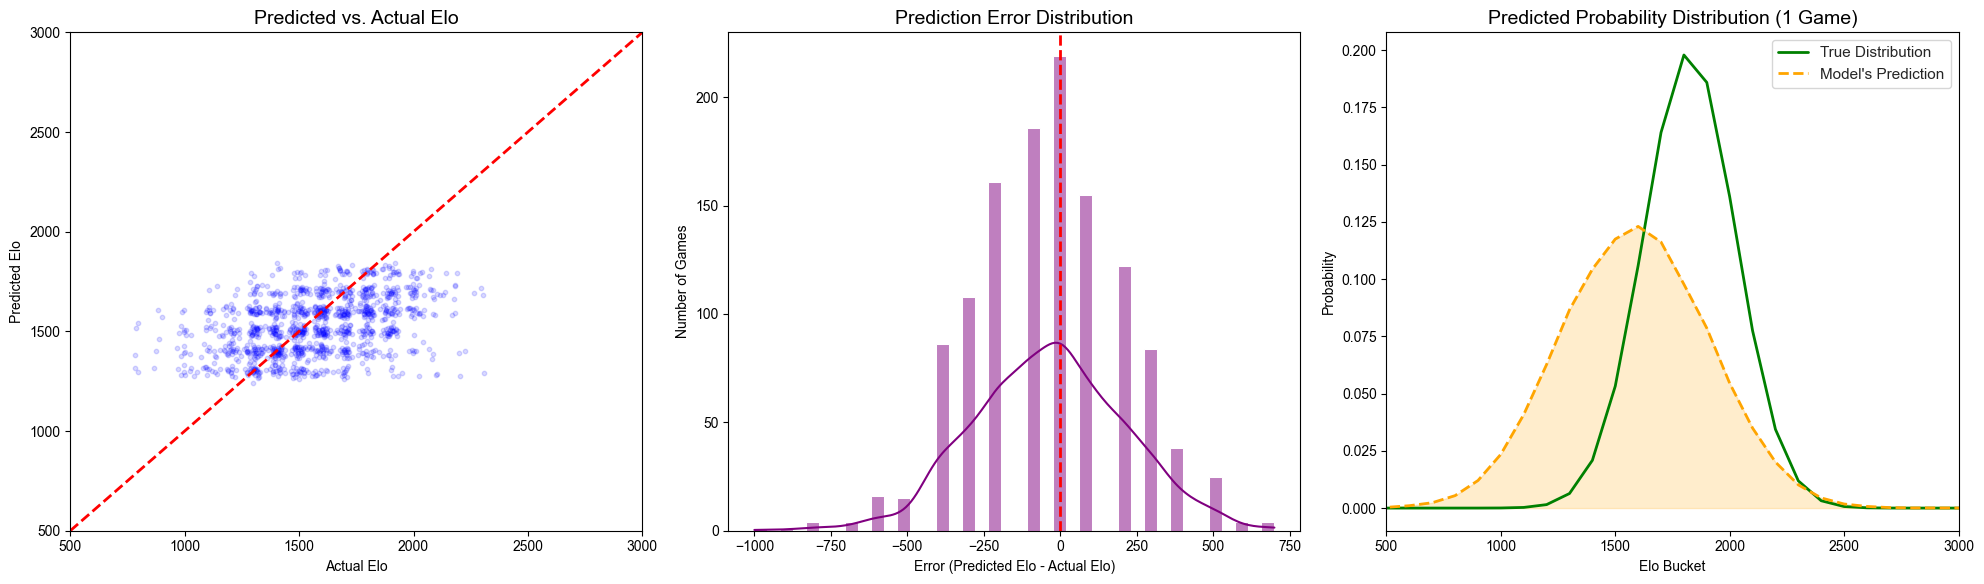

Final Mean Absolute Error (MAE): ±195 Elo points

--- Interpretation of Plots ---
1. The first plot shows how closely the model's predictions match the actual Elo ratings. The closer the blue dots are to the red dashed line, the better the predictions.
2. The second plot shows the distribution of prediction errors. Ideally, we want most errors to be close to zero, which would indicate that the model is generally accurate. A wide spread or a skewed distribution could indicate bias or inconsistency in predictions. The purple bars show how many games had a certain level of error, while the red dashed line at zero indicates perfect predictions. and the purple line shows the overall shape of the error distribution.
3. The third plot shows the predicted probability distribution for a single game compared to the true distribution. The closer the orange dashed line is to the green line, the better the model's understanding of that specific game's Elo rating.


In [22]:
# Set up a 1x3 grid for our plots
from sklearn.metrics import roc_auc_score, roc_curve


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# PLOT 1: Predicted vs. Actual Scatter Plot
# ---------------------------------------------------------
# We add a tiny bit of "jitter" (noise) to the scatter plot so the dots don't completely overlap
jittered_true = all_true_elos + np.random.normal(0, 20, size=len(all_true_elos))
jittered_pred = all_pred_elos + np.random.normal(0, 20, size=len(all_pred_elos))

axes[0].scatter(jittered_true, jittered_pred, alpha=0.15, color='blue', s=10)

# Draw the "Perfect Prediction" diagonal line
min_val, max_val = 500, 3000
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

axes[0].set_title('Predicted vs. Actual Elo', fontsize=14)
axes[0].set_xlabel('Actual Elo')
axes[0].set_ylabel('Predicted Elo')
axes[0].set_xlim(min_val, max_val)
axes[0].set_ylim(min_val, max_val)

# ---------------------------------------------------------
# PLOT 2: Error Distribution (Residuals)
# ---------------------------------------------------------
# Error = Predicted - Actual. If Error is positive, model guessed too high.
errors = all_pred_elos - all_true_elos

sns.histplot(errors, bins=40, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2) # Center line at 0 error

axes[1].set_title('Prediction Error Distribution', fontsize=14)
axes[1].set_xlabel('Error (Predicted Elo - Actual Elo)')
axes[1].set_ylabel('Number of Games')

# ---------------------------------------------------------
# PLOT 3: Single Game Probability Distribution (The Bell Curve)
# ---------------------------------------------------------
buckets = np.arange(0, 4000, 100)

axes[2].plot(buckets, sample_true_dist, label="True Distribution", color='green', linewidth=2)
axes[2].plot(buckets, sample_pred_dist, label="Model's Prediction", color='orange', linewidth=2, linestyle='--')
axes[2].fill_between(buckets, sample_pred_dist, alpha=0.2, color='orange')

axes[2].set_title('Predicted Probability Distribution (1 Game)', fontsize=14)
axes[2].set_xlabel('Elo Bucket')
axes[2].set_ylabel('Probability')
axes[2].set_xlim(500, 3000)
axes[2].legend()

plt.tight_layout()
plt.show()

# Calculate and print final metrics
mae = np.mean(np.abs(errors))
print(f"Final Mean Absolute Error (MAE): ±{mae:.0f} Elo points")
#Explain what each plot means in a print statement
print("\n--- Interpretation of Plots ---")
print("1. The first plot shows how closely the model's predictions match the actual Elo ratings. The closer the blue dots are to the red dashed line, the better the predictions.")
print("2. The second plot shows the distribution of prediction errors. Ideally, we want most errors to be close to zero, which would indicate that the model is generally accurate. A wide spread or a skewed distribution could indicate bias or inconsistency in predictions. The purple bars show how many games had a certain level of error, while the red dashed line at zero indicates perfect predictions. and the purple line shows the overall shape of the error distribution.")
print("3. The third plot shows the predicted probability distribution for a single game compared to the true distribution. The closer the orange dashed line is to the green line, the better the model's understanding of that specific game's Elo rating.")



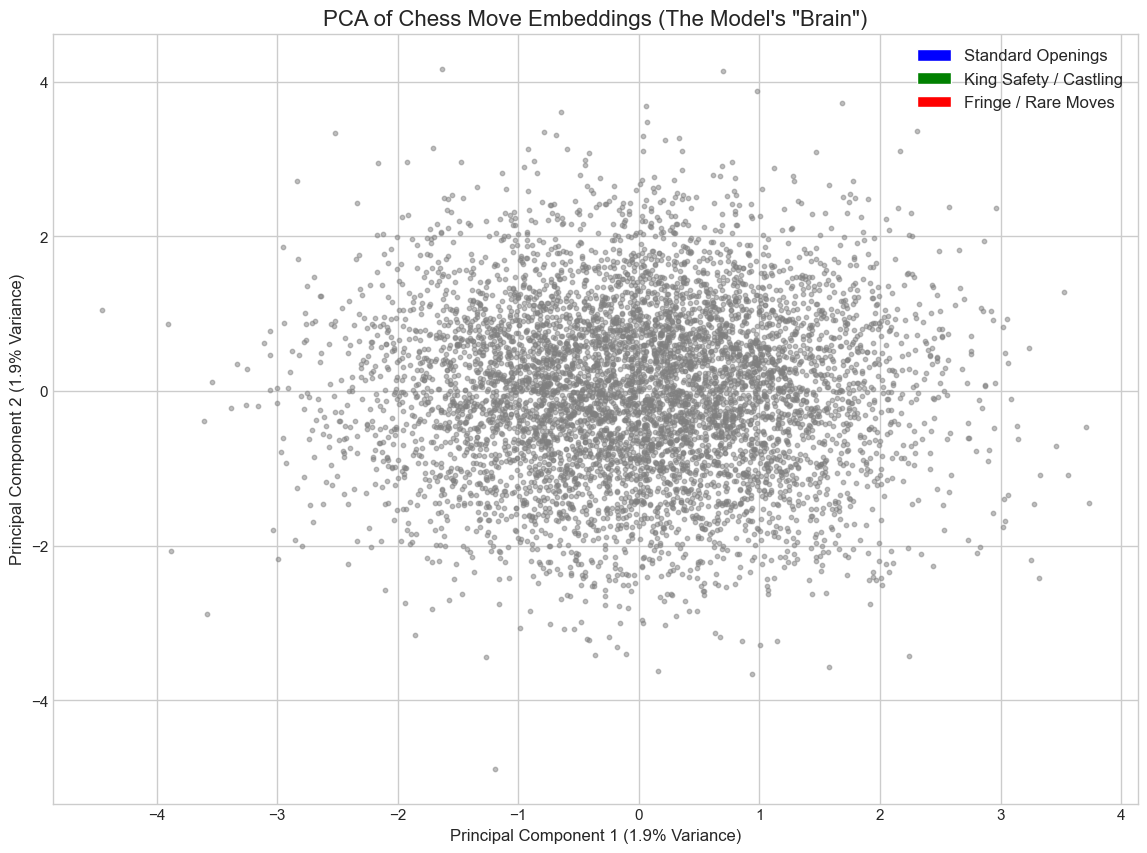

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Load the trained embeddings from your best model
model.load_state_dict(torch.load('distribution_chess_model.pth'))
# Extract the 1910 x 64 embedding matrix
embeddings = model.embedding.weight.detach().cpu().numpy()

# 2. Run PCA to reduce the 64 dimensions down to 2 dimensions
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# 3. Prepare the plot
plt.figure(figsize=(14, 10))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot all moves as light gray background dots
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5, color='gray', s=10)

# 4. FIXED: Translated moves to UCI format
opening_moves = ['e2e4', 'd2d4', 'c2c4', 'g1f3', 'e7e5', 'c7c5']
king_safety = ['e1g1', 'e1c1', 'e8g8', 'e8c8', 'g1h1', 'g8h8'] # Castling and King to corner
blunders_or_rare = ['h2h4', 'a2a4', 'b1a3', 'g1h3', 'h7h5', 'a7a5'] # Edge pawns and weird knight jumps

# Dictionary to map UCI back to readable labels for the plot
uci_to_readable = {
    'e2e4': 'e4', 'd2d4': 'd4', 'c2c4': 'c4', 'g1f3': 'Nf3', 'e7e5': 'e5', 'c7c5': 'c5',
    'e1g1': 'White O-O', 'e1c1': 'White O-O-O', 'e8g8': 'Black O-O', 'e8c8': 'Black O-O-O', 'g1h1': 'Kh1', 'g8h8': 'Kh8',
    'h2h4': 'h4', 'a2a4': 'a4', 'b1a3': 'Na3', 'g1h3': 'Nh3', 'h7h5': 'h5', 'a7a5': 'a5'
}

def plot_highlighted_moves(move_list, color, label_prefix):
    for move in move_list:
        if move in vocab.move_to_id:
            idx = vocab.move_to_id[move]
            x, y = embeddings_2d[idx, 0], embeddings_2d[idx, 1]
            plt.scatter(x, y, color=color, s=80, edgecolors='black', zorder=5)
            
            # Print the readable algebraic notation next to the dot
            readable_move = uci_to_readable.get(move, move)
            plt.text(x + 0.02, y + 0.02, readable_move, fontsize=12, weight='bold', color=color)

# Highlight our categories
plot_highlighted_moves(opening_moves, 'blue', 'Openings')
plot_highlighted_moves(king_safety, 'green', 'King Moves')
plot_highlighted_moves(blunders_or_rare, 'red', 'Edge Pawns/Knights')

plt.title('PCA of Chess Move Embeddings (The Model\'s "Brain")', fontsize=16)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Standard Openings'),
                   Patch(facecolor='green', label='King Safety / Castling'),
                   Patch(facecolor='red', label='Fringe / Rare Moves')]
plt.legend(handles=legend_elements, loc='best', fontsize=12)

plt.show()

Extracting model brain...
Running t-SNE (This may take 10-30 seconds)...


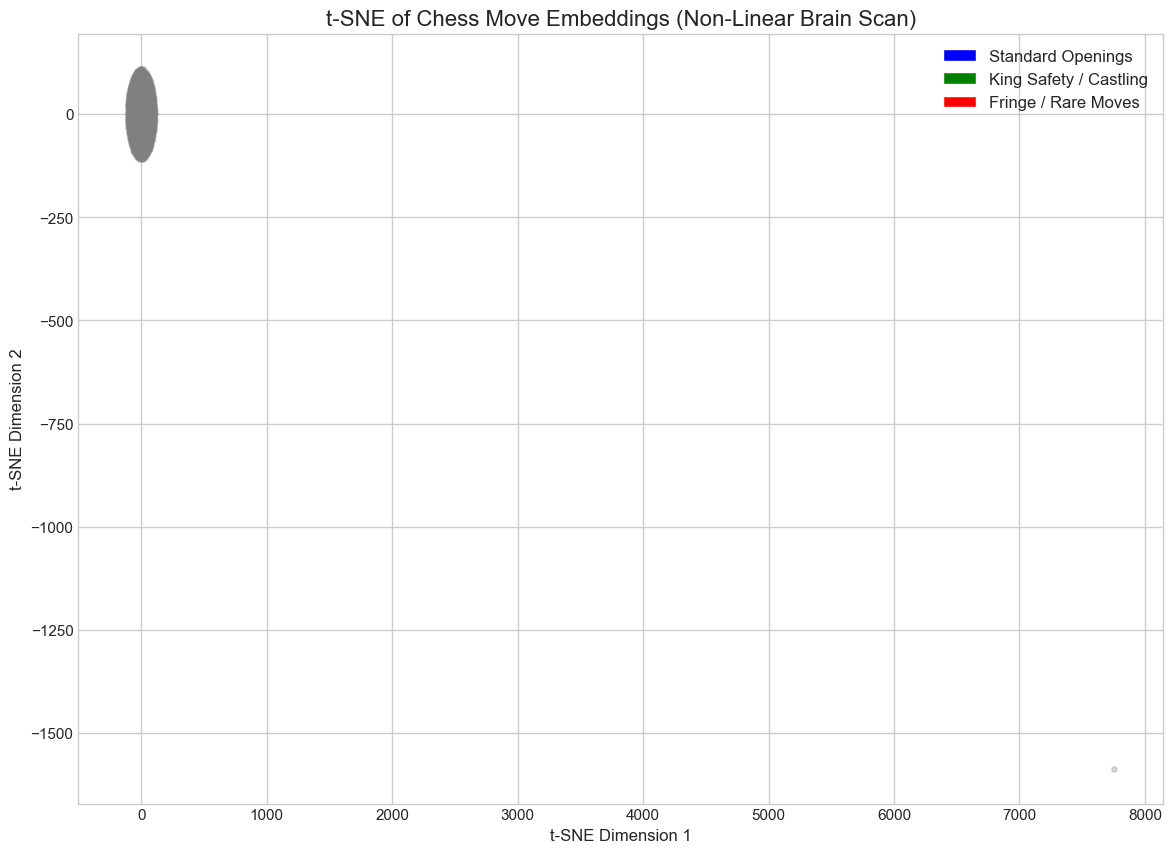

In [24]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects  # <-- NEW IMPORT ADDED HERE
import numpy as np
import torch

print("Extracting model brain...")
# 1. Load the trained embeddings from your best model
model.load_state_dict(torch.load('distribution_chess_model.pth'))
embeddings = model.embedding.weight.detach().cpu().numpy()

# 2. Run t-SNE
print("Running t-SNE (This may take 10-30 seconds)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
embeddings_2d = tsne.fit_transform(embeddings)

# 3. Prepare the plot
plt.figure(figsize=(14, 10))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot all moves as light gray background dots
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.3, color='gray', s=15)

# 4. Our Target Categories (in UCI format)
opening_moves = ['e2e4', 'd2d4', 'c2c4', 'g1f3', 'e7e5', 'c7c5']
king_safety = ['e1g1', 'e1c1', 'e8g8', 'e8c8', 'g1h1', 'g8h8'] 
blunders_or_rare = ['h2h4', 'a2a4', 'b1a3', 'g1h3', 'h7h5', 'a7a5'] 

uci_to_readable = {
    'e2e4': 'e4', 'd2d4': 'd4', 'c2c4': 'c4', 'g1f3': 'Nf3', 'e7e5': 'e5', 'c7c5': 'c5',
    'e1g1': 'White O-O', 'e1c1': 'White O-O-O', 'e8g8': 'Black O-O', 'e8c8': 'Black O-O-O', 'g1h1': 'Kh1', 'g8h8': 'Kh8',
    'h2h4': 'h4', 'a2a4': 'a4', 'b1a3': 'Na3', 'g1h3': 'Nh3', 'h7h5': 'h5', 'a7a5': 'a5'
}

def plot_highlighted_moves(move_list, color, label_prefix):
    for move in move_list:
        if move in vocab.move_to_id:
            idx = vocab.move_to_id[move]
            x, y = embeddings_2d[idx, 0], embeddings_2d[idx, 1]
            plt.scatter(x, y, color=color, s=100, edgecolors='black', zorder=5)
            
            readable_move = uci_to_readable.get(move, move)
            # FIXED: Using the explicitly imported PathEffects module
            plt.text(x + 0.5, y + 0.5, readable_move, fontsize=12, weight='bold', color=color, 
                     path_effects=[PathEffects.withStroke(linewidth=3, foreground='white')])

# Highlight our categories
plot_highlighted_moves(opening_moves, 'blue', 'Openings')
plot_highlighted_moves(king_safety, 'green', 'King Moves')
plot_highlighted_moves(blunders_or_rare, 'red', 'Edge Pawns/Knights')

plt.title('t-SNE of Chess Move Embeddings (Non-Linear Brain Scan)', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Standard Openings'),
                   Patch(facecolor='green', label='King Safety / Castling'),
                   Patch(facecolor='red', label='Fringe / Rare Moves')]
plt.legend(handles=legend_elements, loc='best', fontsize=12)

plt.show()

Loading BEST model to extract Game Vectors...
Processing 2,000 games through the LSTM...


c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Running t-SNE to map the 144-dimensional games to 2D...


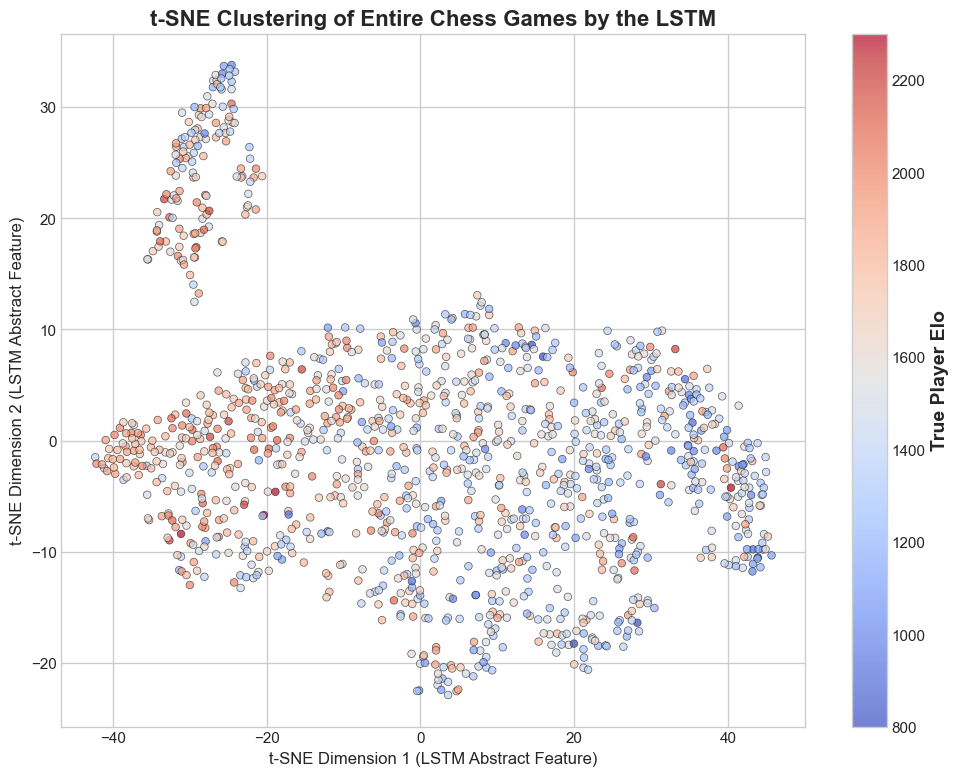

In [25]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch

print("Loading BEST model to extract Game Vectors...")
model.load_state_dict(torch.load('distribution_chess_model.pth'))
model.eval()

game_vectors = []
game_elos = []

print("Processing 2,000 games through the LSTM...")
with torch.no_grad():
    # UNPACK FIX: Added static_feats
    for batch_idx, (moves, clocks, turns, evals, eco_ids, static_feats, labels) in enumerate(test_loader):
        moves, clocks, turns = moves.to(device), clocks.to(device), turns.to(device)
        evals, eco_ids = evals.to(device), eco_ids.to(device)
        static_feats, labels = static_feats.to(device), labels.to(device) # Send to GPU

        # 1. Process Sequences
        embedded_moves = model.embedding(moves)
        embedded_turns = model.turn_embedding(turns)
        clocks_exp = clocks.unsqueeze(-1)
        evals_exp = evals.unsqueeze(-1)
        
        fused_seq = torch.cat((embedded_moves, embedded_turns, clocks_exp, evals_exp), dim=2)
        _, (h_n, _) = model.lstm(fused_seq)
        final_state = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1) 
        
        # 2. Process Static Data
        embedded_eco = model.eco_embedding(eco_ids) 
        processed_static = model.static_fc(static_feats) # NEW: Run static features through the dense layer
        
        # 3. Fuse Everything Together (Shape: [Batch_size, 352])
        combined_features = torch.cat((final_state, embedded_eco, processed_static), dim=1) 
        
        # 4. Save the Game Vectors and True Elos
        game_vectors.extend(combined_features.cpu().numpy())
        
        true_elo = torch.argmax(labels, dim=1) * 100
        game_elos.extend(true_elo.cpu().numpy())
        
        if len(game_vectors) >= 2000:
            break

game_vectors = np.array(game_vectors)
game_elos = np.array(game_elos)

print("Running t-SNE to map the 144-dimensional games to 2D...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
games_2d = tsne.fit_transform(game_vectors)

# --- Plotting the Results ---
plt.figure(figsize=(12, 9))
plt.style.use('seaborn-v0_8-whitegrid')

# Scatter plot colored by Elo! Coolwarm puts Low Elo in Blue, High Elo in Red
scatter = plt.scatter(games_2d[:, 0], games_2d[:, 1], c=game_elos, cmap='coolwarm', alpha=0.7, s=30, edgecolors='k', linewidth=0.5)

# Add a colorbar to show the Elo scale
cbar = plt.colorbar(scatter)
cbar.set_label('True Player Elo', fontsize=14, weight='bold')

plt.title('t-SNE Clustering of Entire Chess Games by the LSTM', fontsize=16, weight='bold')
plt.xlabel('t-SNE Dimension 1 (LSTM Abstract Feature)')
plt.ylabel('t-SNE Dimension 2 (LSTM Abstract Feature)')

plt.show()

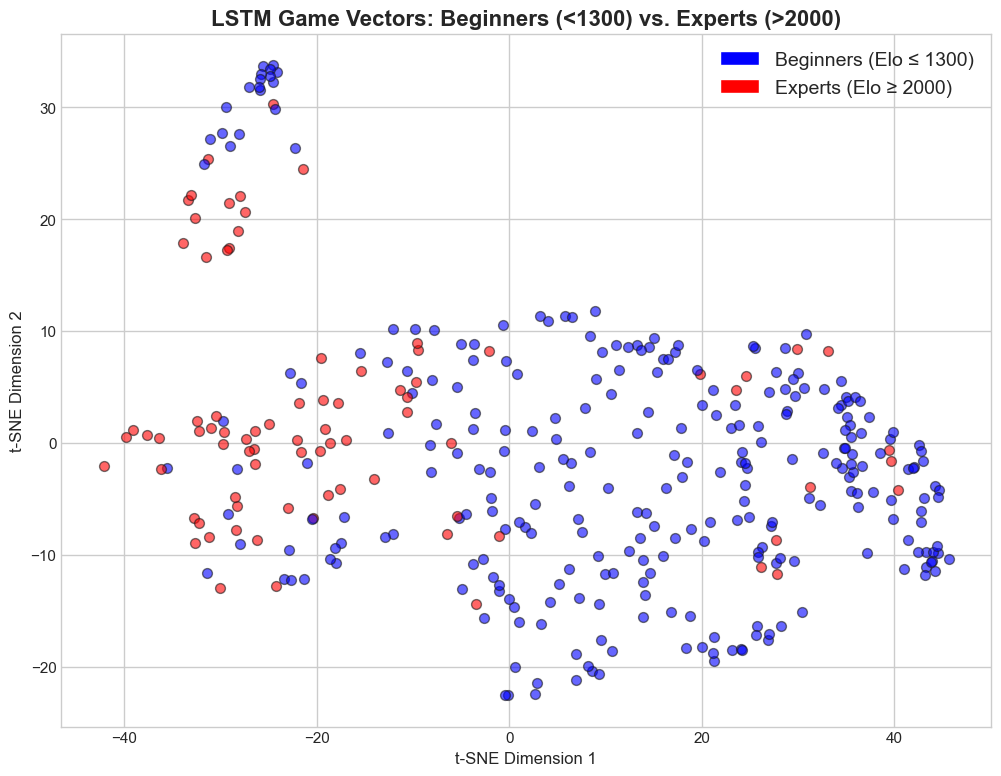

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a mask to ONLY keep Beginners (<1300) and Experts (>2000)
# We are stripping out the "Messy Middle" (1300 - 2000) to see if the network separates the extremes!
extremes_mask = (game_elos <= 1300) | (game_elos >= 2000)

filtered_games_2d = games_2d[extremes_mask]
filtered_elos = game_elos[extremes_mask]

# 2. Prepare the plot
plt.figure(figsize=(12, 9))
plt.style.use('seaborn-v0_8-whitegrid')

# 3. Plot Beginners in Blue, and Masters in Red
# We loop through to give them explicit labels for the legend
for i in range(len(filtered_elos)):
    if filtered_elos[i] <= 1300:
        plt.scatter(filtered_games_2d[i, 0], filtered_games_2d[i, 1], color='blue', alpha=0.6, s=50, edgecolors='k')
    else:
        plt.scatter(filtered_games_2d[i, 0], filtered_games_2d[i, 1], color='red', alpha=0.6, s=50, edgecolors='k')

plt.title('LSTM Game Vectors: Beginners (<1300) vs. Experts (>2000)', fontsize=16, weight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# Create a custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Beginners (Elo ≤ 1300)'),
                   Patch(facecolor='red', label='Experts (Elo ≥ 2000)')]
plt.legend(handles=legend_elements, loc='best', fontsize=14)

plt.show()

Loading BEST model for Feature Importance Analysis...
Calculating Baseline MAE (No shuffling)...


c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Baseline MAE: ±195 Elo

Calculating Feature Importances for 57 total inputs...
--> Shuffled 'moves': +-0.2 Elo penalty
--> Shuffled 'clocks': +-0.1 Elo penalty
--> Shuffled 'evals': +0.2 Elo penalty
--> Shuffled 'eco': +0.0 Elo penalty
--> Shuffled 'tc_base': +0.0 Elo penalty
--> Shuffled 'tc_increment': +-0.1 Elo penalty
--> Shuffled 'total_ply_count': +62.8 Elo penalty
--> Shuffled 'material_balance_end': +1.9 Elo penalty
--> Shuffled 'result_encoded': +0.3 Elo penalty
--> Shuffled 'checks_given_white': +6.6 Elo penalty
--> Shuffled 'checks_given_black': +5.5 Elo penalty
--> Shuffled 'check_density_white': +0.2 Elo penalty
--> Shuffled 'check_density_black': +0.2 Elo penalty
--> Shuffled 'first_capture_move_white': +-0.4 Elo penalty
--> Shuffled 'first_capture_move_black': +-0.4 Elo penalty
--> Shuffled 'pawn_captures_total': +4.2 Elo penalty
--> Shuffled 'piece_captures_total': +2.7 Elo penalty
--> Shuffled 'capture_density': +0.1 Elo penalty
--> Shuffled 'castle_move_white': +-0.6 

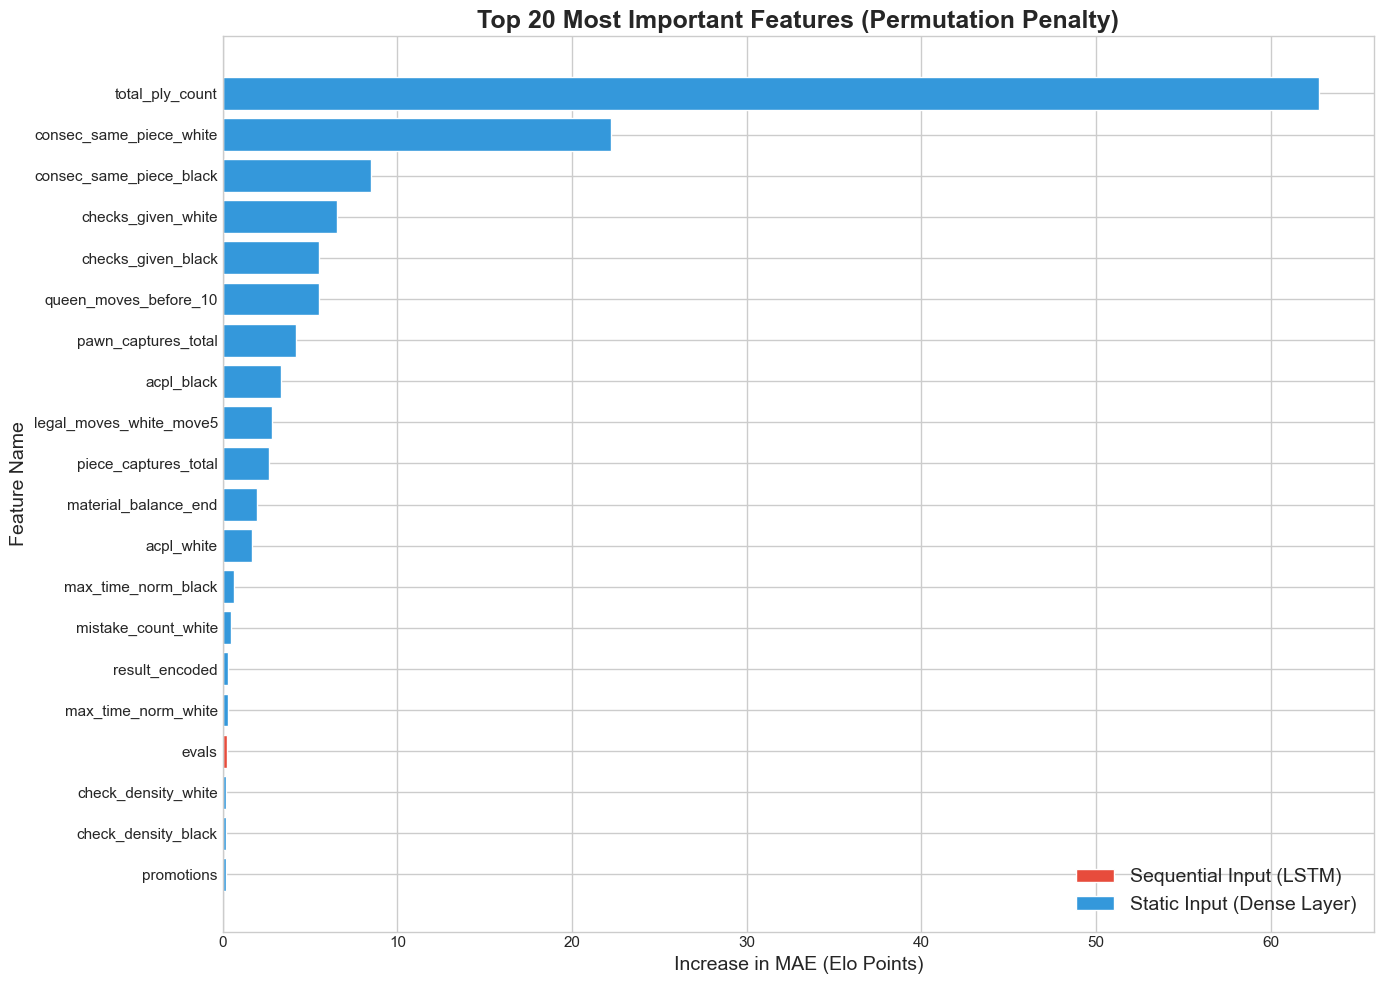

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 7. GRANULAR FEATURE IMPORTANCE
# ==========================================

print("Loading BEST model for Feature Importance Analysis...")
model.load_state_dict(torch.load('distribution_chess_model.pth'))
model.eval()

def get_mae_with_permutation(feature_to_shuffle=None):
    test_mae_elo = 0
    test_samples = 0
    
    with torch.no_grad():
        for batch_idx, (moves, clocks, turns, evals, eco_ids, static_feats, labels) in enumerate(test_loader):
            moves = moves.to(device)
            clocks = clocks.to(device)
            turns = turns.to(device)
            evals = evals.to(device)
            eco_ids = eco_ids.to(device)
            static_feats = static_feats.to(device) 
            labels = labels.to(device)
            
            # --- THE PERMUTATION LOGIC ---
            if feature_to_shuffle == 'moves':
                moves = moves[torch.randperm(moves.size(0))]
            elif feature_to_shuffle == 'clocks':
                clocks = clocks[torch.randperm(clocks.size(0))]
            elif feature_to_shuffle == 'evals':
                evals = evals[torch.randperm(evals.size(0))]
            elif feature_to_shuffle == 'eco':
                eco_ids = eco_ids[torch.randperm(eco_ids.size(0))]
            # --- NEW: Granular Static Feature Shuffling ---
            elif feature_to_shuffle in static_feature_cols:
                # Find exactly which seat this feature is sitting in
                col_idx = static_feature_cols.index(feature_shuffle_name)
                # Shuffle ONLY that specific column across the batch!
                static_feats[:, col_idx] = static_feats[torch.randperm(static_feats.size(0)), col_idx]
                
            log_probs = model(moves, clocks, turns, evals, eco_ids, static_feats)
            
            pred_elo = torch.argmax(log_probs, dim=1) * 100
            true_elo = torch.argmax(labels, dim=1) * 100
            test_mae_elo += torch.abs(pred_elo - true_elo).sum().item()
            test_samples += labels.size(0)
            
            # Stop after 30 batches to save time (increase if you want more precision)
            if batch_idx > 30:
                break
                
    return test_mae_elo / test_samples

print("Calculating Baseline MAE (No shuffling)...")
baseline_mae = get_mae_with_permutation(feature_to_shuffle=None)
print(f"Baseline MAE: ±{baseline_mae:.0f} Elo\n")

# Combine the core sequence features with your 47 new static features!
all_features_to_test = ['moves', 'clocks', 'evals', 'eco'] + static_feature_cols
importances = {}

print(f"Calculating Feature Importances for {len(all_features_to_test)} total inputs...")
for feat in all_features_to_test:
    # Hack to pass the right variable into the function
    global feature_shuffle_name
    feature_shuffle_name = feat 
    
    shuffled_mae = get_mae_with_permutation(feature_to_shuffle=feat)
    importance_score = shuffled_mae - baseline_mae
    importances[feat] = importance_score
    print(f"--> Shuffled '{feat}': +{importance_score:.1f} Elo penalty")

# ==========================================
# PLOTTING THE TOP 20 FEATURES
# ==========================================
plt.figure(figsize=(14, 10))
plt.style.use('seaborn-v0_8-whitegrid')

# Sort features by importance and grab the top 20
sorted_feats = sorted(importances.items(), key=lambda x: x[1], reverse=True)[:20]
names = [x[0] for x in sorted_feats]
scores = [x[1] for x in sorted_feats]

# Highlight the Deep (Sequence) features vs Wide (Static) features
colors = ['#e74c3c' if n in ['moves', 'clocks', 'evals', 'eco'] else '#3498db' for n in names]

# Horizontal bar chart is much easier to read for long names
bars = plt.barh(names[::-1], scores[::-1], color=colors[::-1])
plt.title('Top 20 Most Important Features (Permutation Penalty)', fontsize=18, weight='bold')
plt.xlabel('Increase in MAE (Elo Points)', fontsize=14)
plt.ylabel('Feature Name', fontsize=14)

# Create a custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Sequential Input (LSTM)'),
                   Patch(facecolor='#3498db', label='Static Input (Dense Layer)')]
plt.legend(handles=legend_elements, loc='lower right', fontsize=14)

plt.tight_layout()
plt.show()